### BioSSPy python package test with swallowing audio files
#### Link: https://github.com/PIA-Group/BioSPPy

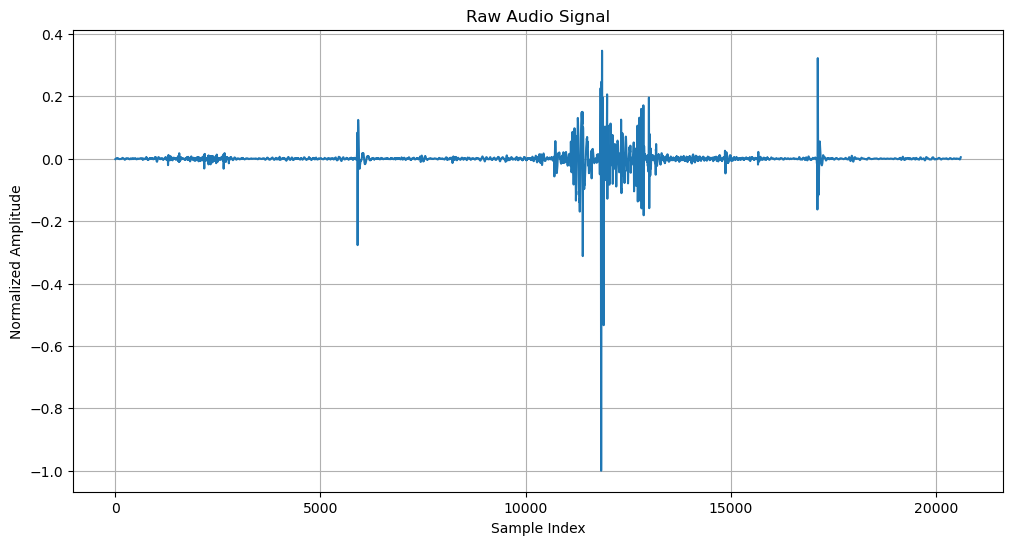

In [4]:
import os
import sys
import biosppy
import scipy
import matplotlib.pyplot as plt
import numpy as np
from biosppy.signals import tools
from scipy.io import wavfile

# Load the audio file
sampling_rate, audio_signal = wavfile.read(r'C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC_F1-3ml.wav')

# Ensure the signal is single-channel (convert stereo to mono)
if len(audio_signal.shape) > 1:
    audio_signal = audio_signal.mean(axis=1)

# Normalize the signal (optional, for better visualization)
audio_signal = audio_signal / np.max(np.abs(audio_signal))

# Plot the raw audio signal
plt.figure(figsize=(12, 6))
plt.plot(audio_signal)
plt.title('Raw Audio Signal')
plt.xlabel('Sample Index')
plt.ylabel('Normalized Amplitude')
plt.grid()
plt.show()

In [5]:
import biosppy
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Load the swallowing sound file
# Replace 'swallowing_sound.wav' with your file
sampling_rate, audio_signal = wavfile.read(r'C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC_F1-3ml.wav')

# Normalize the audio signal (if needed)
audio_signal = audio_signal / np.max(np.abs(audio_signal))

# Preprocess the audio signal
# Biosppy preprocessing includes filtering and visualization
processed = biosppy.signals.tools.filter_signal(
    signal=audio_signal,
    ftype='FIR',  # Finite Impulse Response filter
    band='bandpass',  # Band-pass filter
    order=4,  # Filter order
    frequency=[50, 1000],  # Passband in Hz (adjust based on swallowing sound characteristics)
    sampling_rate=sampling_rate
)

# Extract filtered signal
filtered_signal = processed['signal']

# Plot raw and filtered signals
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.title("Raw Swallowing Sound Signal")
plt.plot(audio_signal)
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.title("Filtered Swallowing Sound Signal")
plt.plot(filtered_signal)
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Extract features using biosppy.tools
# Example: Compute signal energy and zero-crossing rate
def compute_features(signal, sampling_rate):
    # Signal Energy
    energy = np.sum(signal**2)

    # Zero-Crossing Rate (ZCR)
    zcr = np.sum(np.diff(np.sign(signal)) != 0) / len(signal)

    # RMS (Root Mean Square)
    rms = np.sqrt(np.mean(signal**2))

    return {
        "Energy": energy,
        "Zero-Crossing Rate": zcr,
        "RMS": rms,
    }

features = compute_features(filtered_signal, sampling_rate)

# Display extracted features
print("Extracted Features:")
for key, value in features.items():from scipy.signal import spectrogram
import matplotlib.pyplot as plt

# Compute and plot the spectrogram
frequencies, times, Sxx = spectrogram(audio_signal, fs=sampling_rate)

plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')
plt.title("Spectrogram of Swallowing Sound")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.colorbar(label="Power (dB)")
plt.ylim(0, 2000)  # Limit the frequency range for clarity
plt.show()

print(f"{key}: {value:.4f}")


ModuleNotFoundError: No module named 'pywt'

## Filtering test with healthy and disease audio

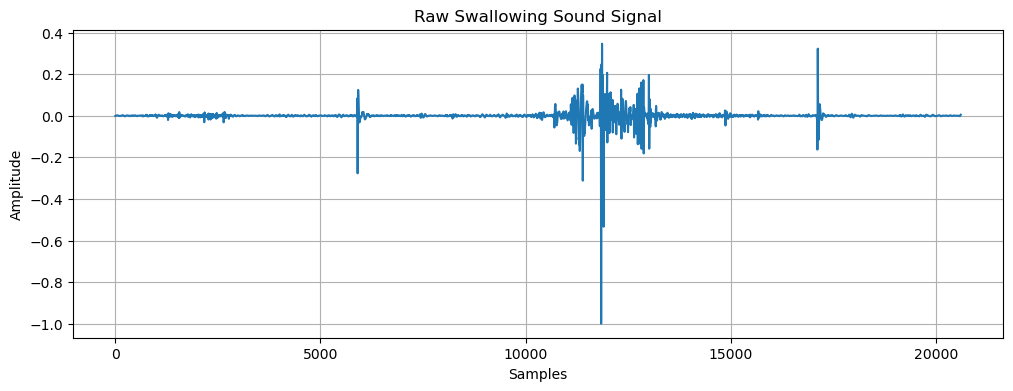

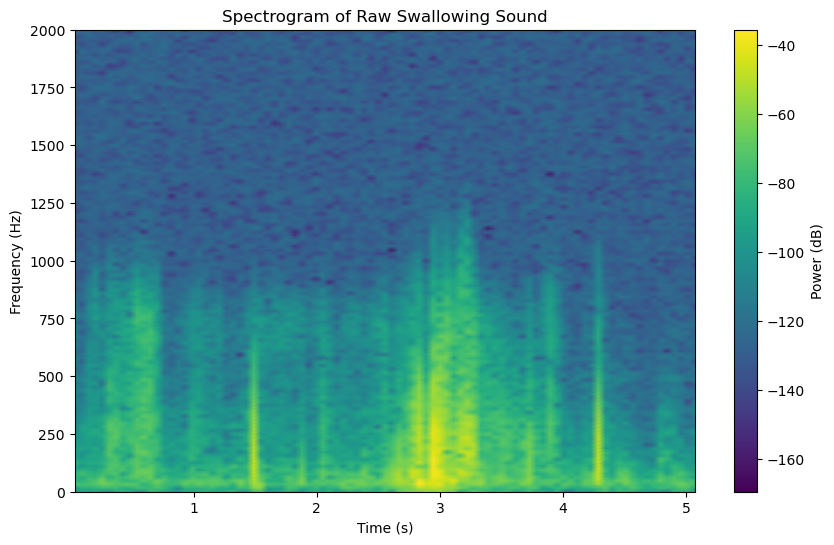

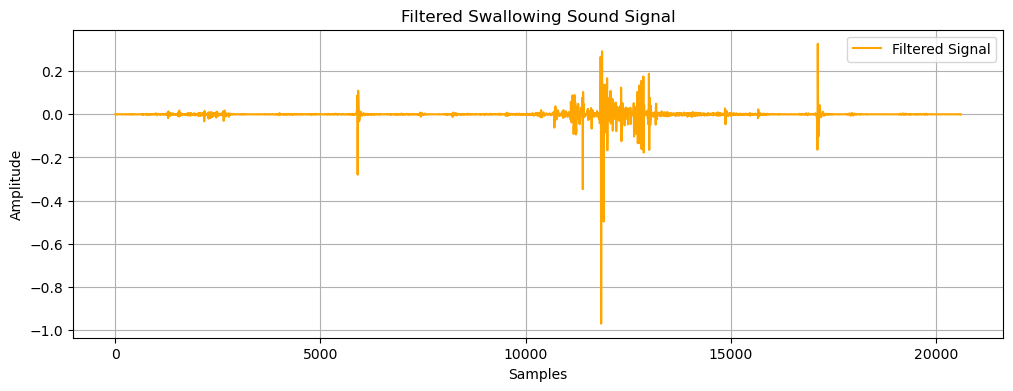

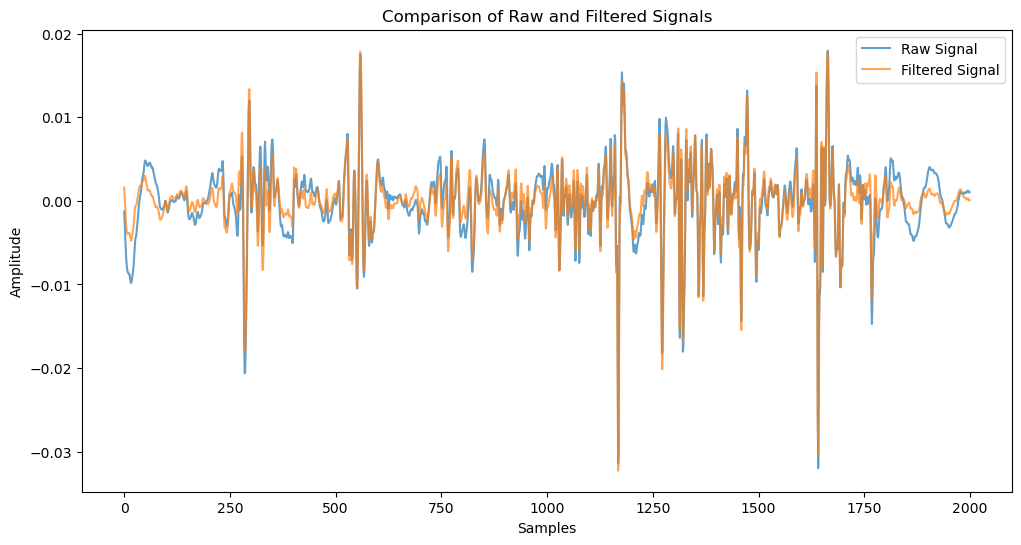

Raw Signal Features:
Energy: 15.7494
Zero-Crossing Rate: 0.0640
RMS: 0.0276

Filtered Signal Features:
Energy: 12.3172
Zero-Crossing Rate: 0.0644
RMS: 0.0244


In [18]:
import numpy as np
from scipy.io import wavfile
from scipy.signal import butter, filtfilt, spectrogram
import matplotlib.pyplot as plt
from biosppy.signals.tools import filter_signal

# Step 1: Load the audio file
audio_file = r'C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC_F1-3ml.wav'  # Replace with your audio file
sampling_rate, audio_signal = wavfile.read(audio_file)

# Normalize the audio signal to [-1, 1] range (if not already normalized)
audio_signal = audio_signal / np.max(np.abs(audio_signal))

# Step 2: Analyze the raw signal (time and frequency domain)
# Plot the raw signal
plt.figure(figsize=(12, 4))
plt.plot(audio_signal)
plt.title("Raw Swallowing Sound Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Compute and plot the spectrogram to identify frequency components
frequencies, times, Sxx = spectrogram(audio_signal, fs=sampling_rate)

plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')
plt.title("Spectrogram of Raw Swallowing Sound")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.colorbar(label="Power (dB)")
plt.ylim(0, 2000)  # Adjust frequency range for clarity
plt.show()

# Step 3: Apply a bandpass filter
# Define bandpass filter parameters
low_cutoff = 50    # Adjust based on spectrogram analysis
high_cutoff = 1000 # Adjust based on spectrogram analysis

# Design and apply a Butterworth bandpass filter
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered_data = filtfilt(b, a, data)
    return filtered_data

filtered_signal = butter_bandpass_filter(audio_signal, low_cutoff, high_cutoff, sampling_rate)

# Step 4: Plot the filtered signal
plt.figure(figsize=(12, 4))
plt.plot(filtered_signal, color='orange', label="Filtered Signal")
plt.title("Filtered Swallowing Sound Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

# Compare a small section of the raw and filtered signals
start_sample, end_sample = 1000, 3000
plt.figure(figsize=(12, 6))
plt.plot(audio_signal[start_sample:end_sample], label="Raw Signal", alpha=0.7)
plt.plot(filtered_signal[start_sample:end_sample], label="Filtered Signal", alpha=0.7)
plt.title("Comparison of Raw and Filtered Signals")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

# Step 5: Extract Basic Features
def compute_features(signal, sampling_rate):
    energy = np.sum(signal**2)  # Signal energy
    zcr = np.sum(np.diff(np.sign(signal)) != 0) / len(signal)  # Zero-Crossing Rate
    rms = np.sqrt(np.mean(signal**2))  # Root Mean Square
    return {"Energy": energy, "Zero-Crossing Rate": zcr, "RMS": rms}

raw_features = compute_features(audio_signal, sampling_rate)
filtered_features = compute_features(filtered_signal, sampling_rate)

print("Raw Signal Features:")
for key, value in raw_features.items():
    print(f"{key}: {value:.4f}")

print("\nFiltered Signal Features:")
for key, value in filtered_features.items():
    print(f"{key}: {value:.4f}")


The metrics applied

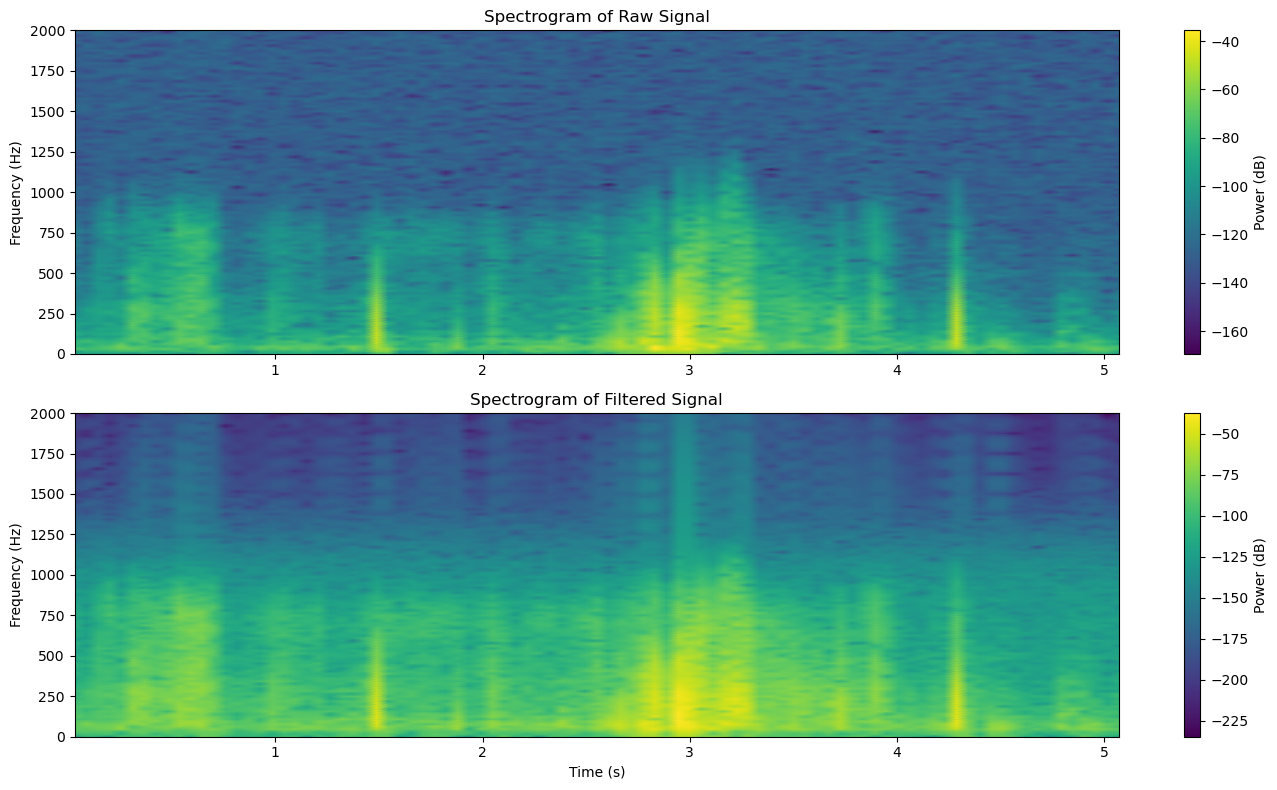

In [20]:
# Overlay spectrograms of raw and filtered signals
frequencies_raw, times_raw, Sxx_raw = spectrogram(audio_signal, fs=sampling_rate)
frequencies_filtered, times_filtered, Sxx_filtered = spectrogram(filtered_signal, fs=sampling_rate)

plt.figure(figsize=(14, 8))

# Raw Signal Spectrogram
plt.subplot(2, 1, 1)
plt.pcolormesh(times_raw, frequencies_raw, 10 * np.log10(Sxx_raw), shading='gouraud')
plt.title("Spectrogram of Raw Signal")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Power (dB)")
plt.ylim(0, 2000)

# Filtered Signal Spectrogram
plt.subplot(2, 1, 2)
plt.pcolormesh(times_filtered, frequencies_filtered, 10 * np.log10(Sxx_filtered), shading='gouraud')
plt.title("Spectrogram of Filtered Signal")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.colorbar(label="Power (dB)")
plt.ylim(0, 2000)

plt.tight_layout()
plt.show()


## Dysphagia audio 5ml


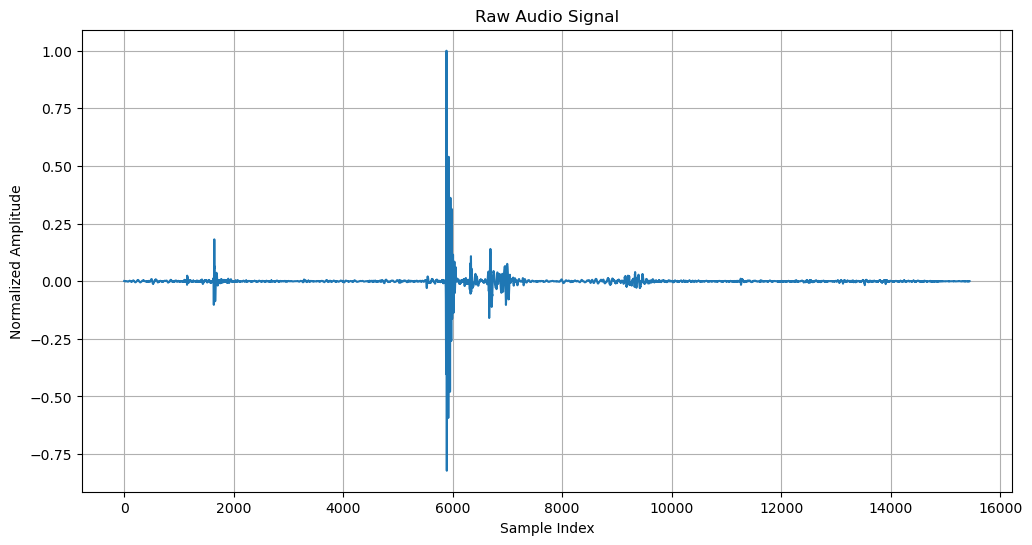

In [2]:
import os
import sys
import biosppy
import scipy
import matplotlib.pyplot as plt
import numpy as np
from biosppy.signals import tools
from scipy.io import wavfile

# Load the audio file
sampling_rate, audio_signal = wavfile.read(r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GE_F1_3ML - S.wav")

# Ensure the signal is single-channel (convert stereo to mono)
if len(audio_signal.shape) > 1:
    audio_signal = audio_signal.mean(axis=1)

# Normalize the signal (optional, for better visualization)
audio_signal = audio_signal / np.max(np.abs(audio_signal))

# Plot the raw audio signal
plt.figure(figsize=(12, 6))
plt.plot(audio_signal)
plt.title('Raw Audio Signal')
plt.xlabel('Sample Index')
plt.ylabel('Normalized Amplitude')
plt.grid()
plt.show()

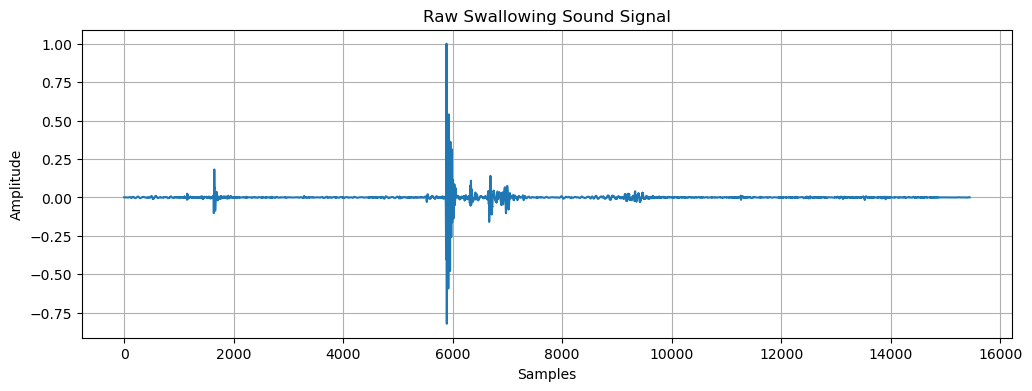

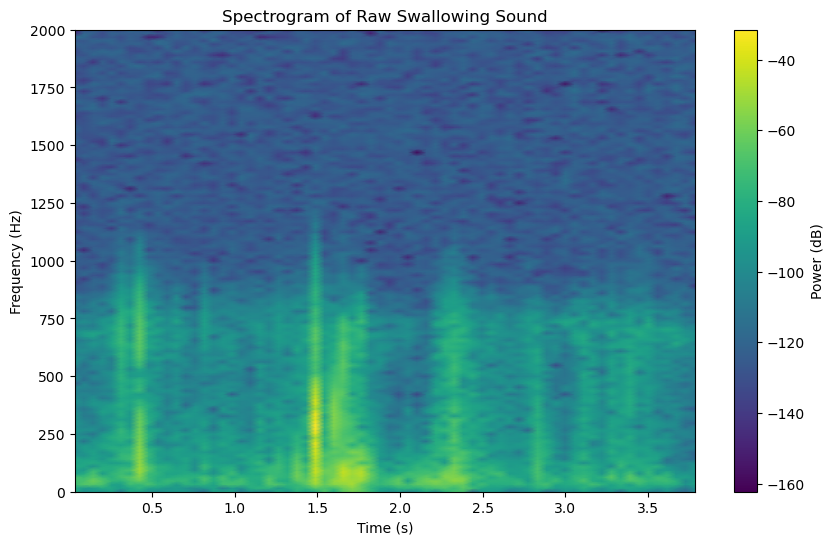

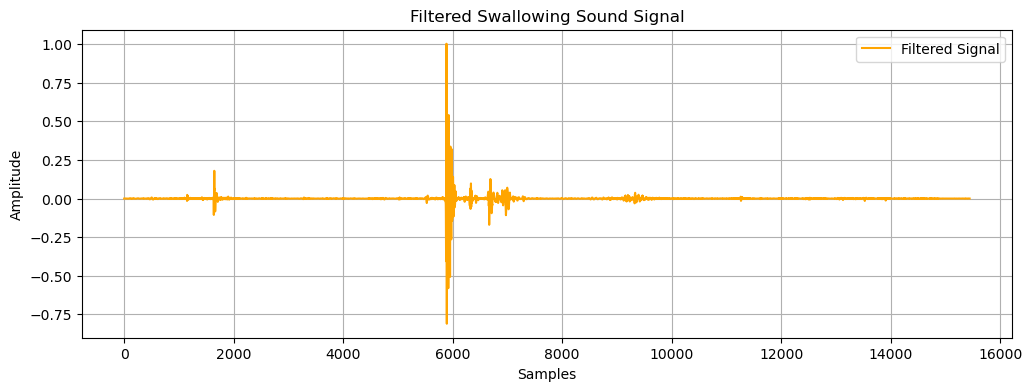

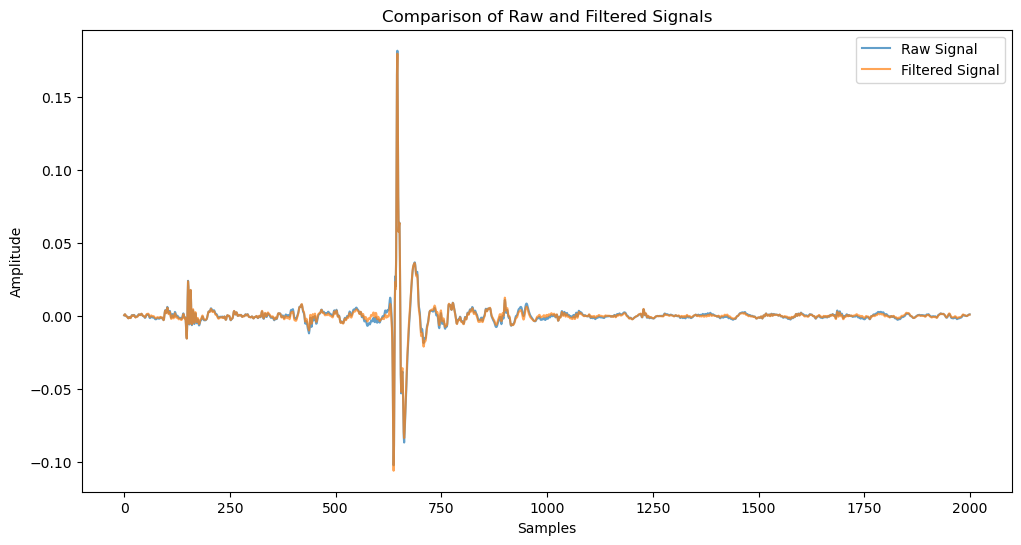

Raw Signal Features:
Energy: 15.6799
Zero-Crossing Rate: 0.1081
RMS: 0.0319

Filtered Signal Features:
Energy: 15.2791
Zero-Crossing Rate: 0.1081
RMS: 0.0315


In [3]:
import numpy as np
from scipy.io import wavfile
from scipy.signal import butter, filtfilt, spectrogram
import matplotlib.pyplot as plt
from biosppy.signals.tools import filter_signal

# Step 1: Load the audio file
audio_file = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GE_F1_3ML - S.wav" 
sampling_rate, audio_signal = wavfile.read(audio_file)

# Normalize the audio signal to [-1, 1] range (if not already normalized)
audio_signal = audio_signal / np.max(np.abs(audio_signal))

# Step 2: Analyze the raw signal (time and frequency domain)
# Plot the raw signal
plt.figure(figsize=(12, 4))
plt.plot(audio_signal)
plt.title("Raw Swallowing Sound Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Compute and plot the spectrogram to identify frequency components
frequencies, times, Sxx = spectrogram(audio_signal, fs=sampling_rate)

plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')
plt.title("Spectrogram of Raw Swallowing Sound")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.colorbar(label="Power (dB)")
plt.ylim(0, 2000)  # Adjust frequency range for clarity
plt.show()

# Step 3: Apply a bandpass filter
# Define bandpass filter parameters
low_cutoff = 50    # Adjust based on spectrogram analysis
high_cutoff = 1000 # Adjust based on spectrogram analysis

# Design and apply a Butterworth bandpass filter
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered_data = filtfilt(b, a, data)
    return filtered_data

filtered_signal = butter_bandpass_filter(audio_signal, low_cutoff, high_cutoff, sampling_rate)

# Step 4: Plot the filtered signal
plt.figure(figsize=(12, 4))
plt.plot(filtered_signal, color='orange', label="Filtered Signal")
plt.title("Filtered Swallowing Sound Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

# Compare a small section of the raw and filtered signals
start_sample, end_sample = 1000, 3000
plt.figure(figsize=(12, 6))
plt.plot(audio_signal[start_sample:end_sample], label="Raw Signal", alpha=0.7)
plt.plot(filtered_signal[start_sample:end_sample], label="Filtered Signal", alpha=0.7)
plt.title("Comparison of Raw and Filtered Signals")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

# Step 5: Extract Basic Features
def compute_features(signal, sampling_rate):
    energy = np.sum(signal**2)  # Signal energy
    zcr = np.sum(np.diff(np.sign(signal)) != 0) / len(signal)  # Zero-Crossing Rate
    rms = np.sqrt(np.mean(signal**2))  # Root Mean Square
    return {"Energy": energy, "Zero-Crossing Rate": zcr, "RMS": rms}

raw_features = compute_features(audio_signal, sampling_rate)
filtered_features = compute_features(filtered_signal, sampling_rate)

print("Raw Signal Features:")
for key, value in raw_features.items():
    print(f"{key}: {value:.4f}")

print("\nFiltered Signal Features:")
for key, value in filtered_features.items():
    print(f"{key}: {value:.4f}")


----------------------------------------------------------------------------------------------------------------------------------------

#### Other methods

#### GC_F1-3ml

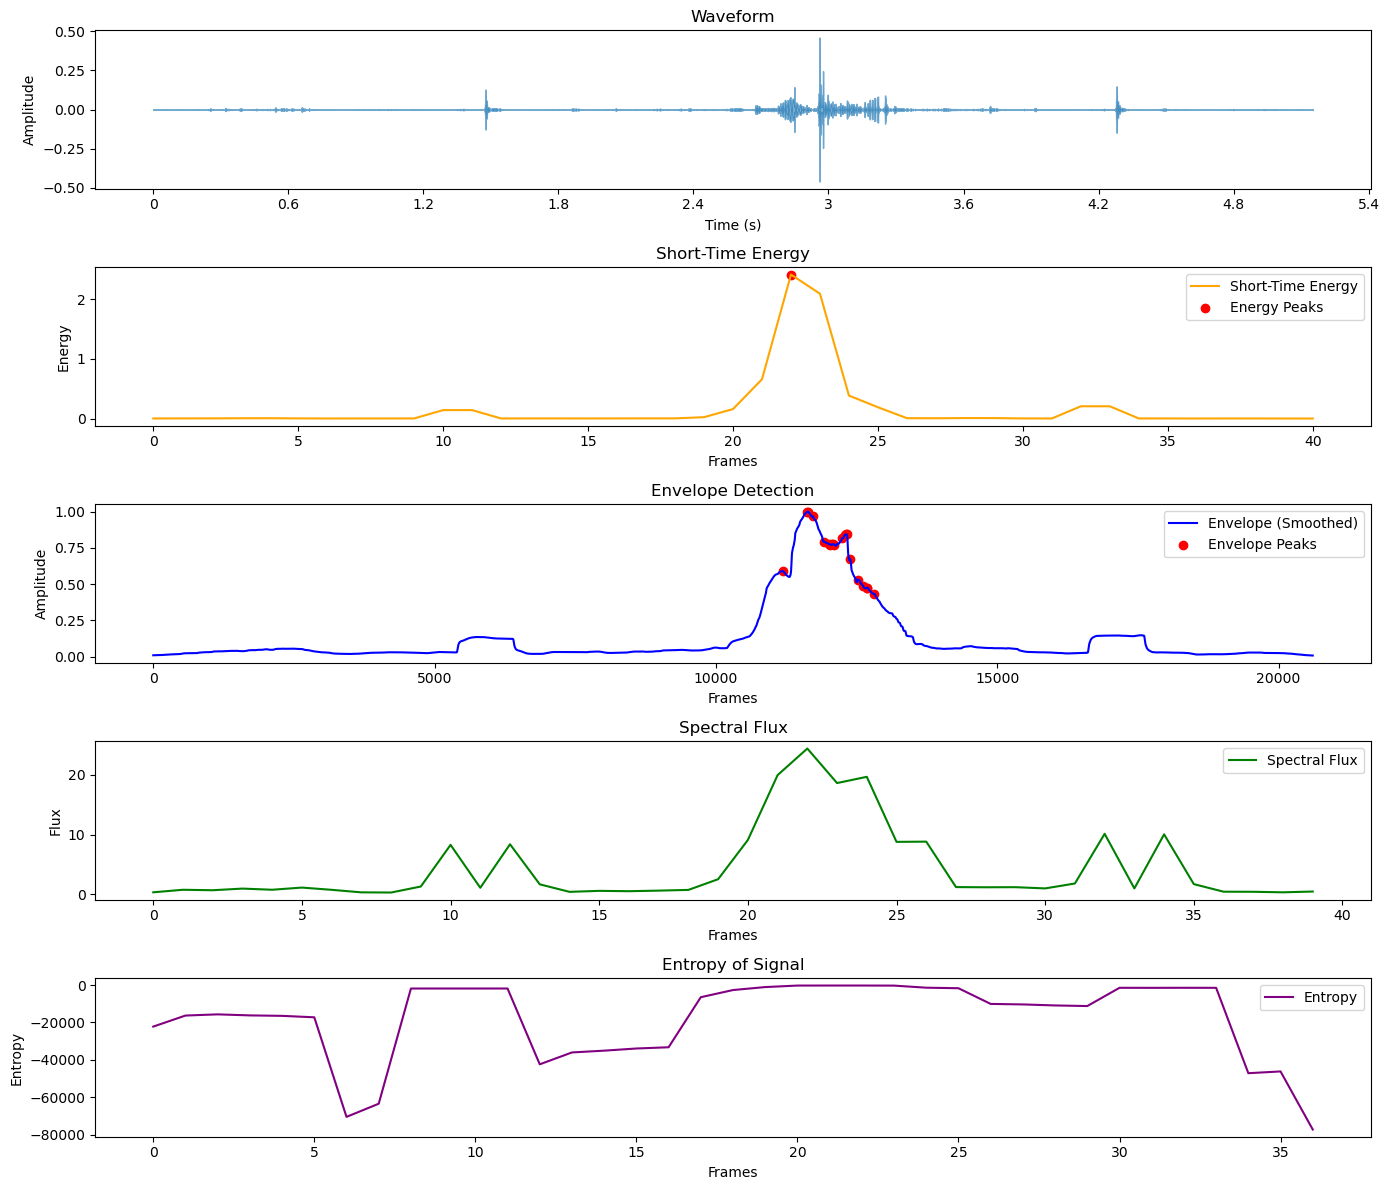

Detected Energy Peaks (frames): [22]
Detected Envelope Peaks (frames): [11190 11615 11631 11717 11921 12002 12034 12070 12087 12103 12246 12295
 12304 12325 12379 12524 12618 12677 12693 12816]


In [10]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import hilbert


# Load the audio file
audio_path = r'C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC_F1-3ml.wav' 
y, sr = librosa.load(audio_path, sr=None)

# 1. Short-Time Energy (STE)
frame_length = 1024
hop_length = 512
energy = np.array([
    np.sum(np.abs(y[i:i+frame_length])**2)
    for i in range(0, len(y), hop_length)
])

# 2. Envelope Detection
envelope = np.abs(hilbert(y))
envelope_smoothed = librosa.util.normalize(np.convolve(envelope, np.ones(1000)/1000, mode='same'))

# 3. Spectral Flux
spectrogram = np.abs(librosa.stft(y, n_fft=2048, hop_length=hop_length))
spectral_flux = np.sqrt(np.sum(np.diff(spectrogram, axis=1)**2, axis=0))

# 4. Entropy Calculation
def entropy(signal):
    probability_distribution, _ = np.histogram(signal, bins=50, density=True)
    probability_distribution = probability_distribution[probability_distribution > 0]
    return -np.sum(probability_distribution * np.log2(probability_distribution))

window_size = 2048
entropy_values = [
    entropy(y[i:i+window_size])
    for i in range(0, len(y) - window_size, hop_length)
]

# 5. Find Peaks in Energy and Envelope
energy_peaks, _ = find_peaks(energy, height=np.mean(energy) + 1.5 * np.std(energy))
envelope_peaks, _ = find_peaks(envelope_smoothed, height=np.mean(envelope_smoothed) + 1.5 * np.std(envelope_smoothed))

# Plotting Results
plt.figure(figsize=(14, 12))

# 1. Waveform
plt.subplot(5, 1, 1)
librosa.display.waveshow(y, sr=sr, alpha=0.6)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# 2. Short-Time Energy (STE)
plt.subplot(5, 1, 2)
plt.plot(energy, label="Short-Time Energy", color="orange")
plt.scatter(energy_peaks, energy[energy_peaks], color="red", label="Energy Peaks")
plt.title("Short-Time Energy")
plt.xlabel("Frames")
plt.ylabel("Energy")
plt.legend()

# 3. Envelope
plt.subplot(5, 1, 3)
plt.plot(envelope_smoothed, label="Envelope (Smoothed)", color="blue")
plt.scatter(envelope_peaks, envelope_smoothed[envelope_peaks], color="red", label="Envelope Peaks")
plt.title("Envelope Detection")
plt.xlabel("Frames")
plt.ylabel("Amplitude")
plt.legend()

# 4. Spectral Flux
plt.subplot(5, 1, 4)
plt.plot(spectral_flux, label="Spectral Flux", color="green")
plt.title("Spectral Flux")
plt.xlabel("Frames")
plt.ylabel("Flux")
plt.legend()

# 5. Entropy
plt.subplot(5, 1, 5)
plt.plot(entropy_values, label="Entropy", color="purple")
plt.title("Entropy of Signal")
plt.xlabel("Frames")
plt.ylabel("Entropy")
plt.legend()

plt.tight_layout()
plt.show()

# Print Detected Peaks
print("Detected Energy Peaks (frames):", energy_peaks)
print("Detected Envelope Peaks (frames):", envelope_peaks)


#### GE_F1_3ML

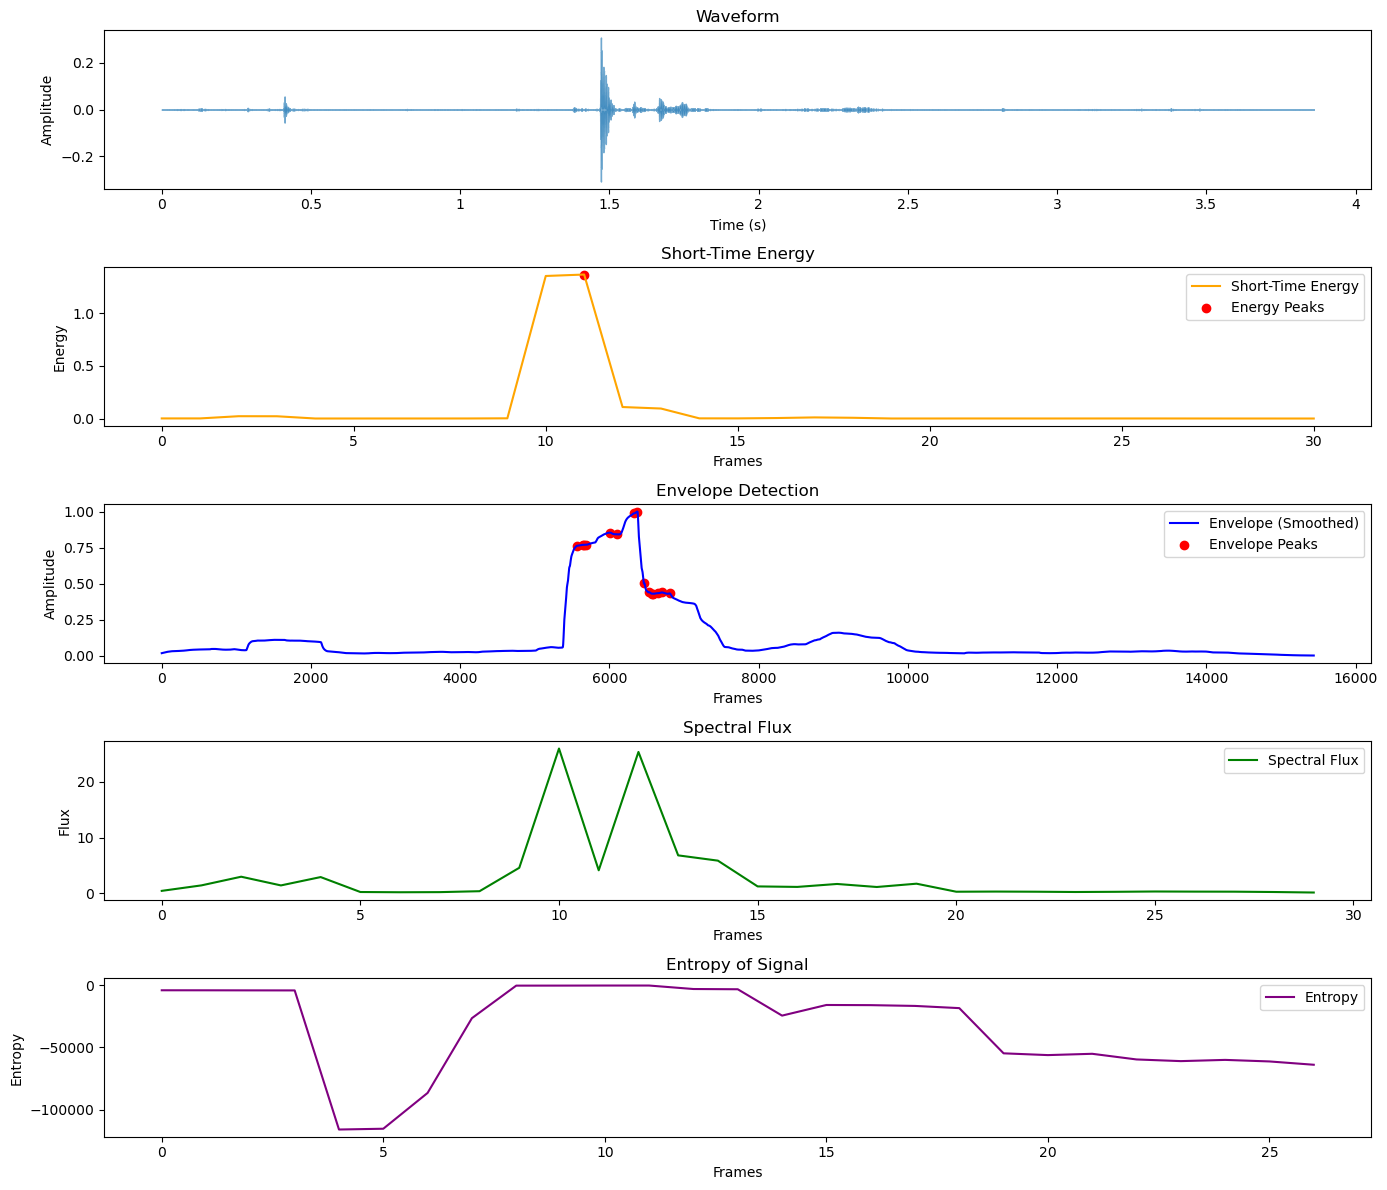

Detected Energy Peaks (frames): [11]
Detected Envelope Peaks (frames): [5570 5641 5661 5685 6008 6099 6325 6374 6468 6527 6573 6578 6647 6704
 6806]


In [11]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import hilbert


# Load the audio file
audio_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GE_F1_3ML - S.wav" 
y, sr = librosa.load(audio_path, sr=None)

# 1. Short-Time Energy (STE)
frame_length = 1024
hop_length = 512
energy = np.array([
    np.sum(np.abs(y[i:i+frame_length])**2)
    for i in range(0, len(y), hop_length)
])

# 2. Envelope Detection
envelope = np.abs(hilbert(y))
envelope_smoothed = librosa.util.normalize(np.convolve(envelope, np.ones(1000)/1000, mode='same'))

# 3. Spectral Flux
spectrogram = np.abs(librosa.stft(y, n_fft=2048, hop_length=hop_length))
spectral_flux = np.sqrt(np.sum(np.diff(spectrogram, axis=1)**2, axis=0))

# 4. Entropy Calculation
def entropy(signal):
    probability_distribution, _ = np.histogram(signal, bins=50, density=True)
    probability_distribution = probability_distribution[probability_distribution > 0]
    return -np.sum(probability_distribution * np.log2(probability_distribution))

window_size = 2048
entropy_values = [
    entropy(y[i:i+window_size])
    for i in range(0, len(y) - window_size, hop_length)
]

# 5. Find Peaks in Energy and Envelope
energy_peaks, _ = find_peaks(energy, height=np.mean(energy) + 1.5 * np.std(energy))
envelope_peaks, _ = find_peaks(envelope_smoothed, height=np.mean(envelope_smoothed) + 1.5 * np.std(envelope_smoothed))

# Plotting Results
plt.figure(figsize=(14, 12))

# 1. Waveform
plt.subplot(5, 1, 1)
librosa.display.waveshow(y, sr=sr, alpha=0.6)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# 2. Short-Time Energy (STE)
plt.subplot(5, 1, 2)
plt.plot(energy, label="Short-Time Energy", color="orange")
plt.scatter(energy_peaks, energy[energy_peaks], color="red", label="Energy Peaks")
plt.title("Short-Time Energy")
plt.xlabel("Frames")
plt.ylabel("Energy")
plt.legend()

# 3. Envelope
plt.subplot(5, 1, 3)
plt.plot(envelope_smoothed, label="Envelope (Smoothed)", color="blue")
plt.scatter(envelope_peaks, envelope_smoothed[envelope_peaks], color="red", label="Envelope Peaks")
plt.title("Envelope Detection")
plt.xlabel("Frames")
plt.ylabel("Amplitude")
plt.legend()

# 4. Spectral Flux
plt.subplot(5, 1, 4)
plt.plot(spectral_flux, label="Spectral Flux", color="green")
plt.title("Spectral Flux")
plt.xlabel("Frames")
plt.ylabel("Flux")
plt.legend()

# 5. Entropy
plt.subplot(5, 1, 5)
plt.plot(entropy_values, label="Entropy", color="purple")
plt.title("Entropy of Signal")
plt.xlabel("Frames")
plt.ylabel("Entropy")
plt.legend()

plt.tight_layout()
plt.show()

# Print Detected Peaks
print("Detected Energy Peaks (frames):", energy_peaks)
print("Detected Envelope Peaks (frames):", envelope_peaks)
